## Análisis de Ventas de Videojuegos

Este notebook explora las ventas globales de videojuegos por plataforma, género, año y publisher, utilizando Pandas y Matplotlib.
El objetivo es identificar patrones y tendencias en la industria de los videojuegos a lo largo de las décadas.

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
## Cargar datos

In [7]:
df = pd.read_csv('vgsales.csv')

In [8]:
## Exploracion Basica

In [9]:
print("=== Primeras 5 filas ===")
print(df.head())
print("\n=== Informacion ===")
print(df.info())
print("\n=== Estadisticas ===")
print(df.describe())

=== Primeras 5 filas ===
   Rank                      Name Platform    Year         Genre Publisher  \
0     1                Wii Sports      Wii  2006.0        Sports  Nintendo   
1     2         Super Mario Bros.      NES  1985.0      Platform  Nintendo   
2     3            Mario Kart Wii      Wii  2008.0        Racing  Nintendo   
3     4         Wii Sports Resort      Wii  2009.0        Sports  Nintendo   
4     5  Pokemon Red/Pokemon Blue       GB  1996.0  Role-Playing  Nintendo   

   NA_Sales  EU_Sales  JP_Sales  Other_Sales  Global_Sales  
0     41.49     29.02      3.77         8.46         82.74  
1     29.08      3.58      6.81         0.77         40.24  
2     15.85     12.88      3.79         3.31         35.82  
3     15.75     11.01      3.28         2.96         33.00  
4     11.27      8.89     10.22         1.00         31.37  

=== Informacion ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16598 entries, 0 to 16597
Data columns (total 11 columns):
 #   Colum

In [10]:
## Limpiar columna Year

In [11]:
df['Year'] = pd.to_numeric(df['Year'], errors='coerce')
df = df.dropna(subset=['Year'])
df['Year'] = df['Year'].astype(int)

In [12]:
## Crear columna de ventas totales por región

In [15]:
df['Total_Region_Sales'] = df['NA_Sales'] + df['EU_Sales'] + df['JP_Sales'] + df['Other_Sales']

In [16]:
## Verificar que coinciden con Global_Sales

In [17]:
print("\n=== Diferencias entre Total_Region_Sales y Global_Sales ===")
print((df['Total_Region_Sales'] - df['Global_Sales']).abs().max())


=== Diferencias entre Total_Region_Sales y Global_Sales ===
0.020000000000000462


In [18]:
## Analisis por plataforma: top 10 por ventas globales


=== Top 10 plataformas por ventas globales ===
Platform
PS2     1233.46
X360     969.61
PS3      949.35
Wii      909.81
DS       818.96
PS       727.39
GBA      313.56
PSP      291.71
PS4      278.10
PC       255.05
Name: Global_Sales, dtype: float64


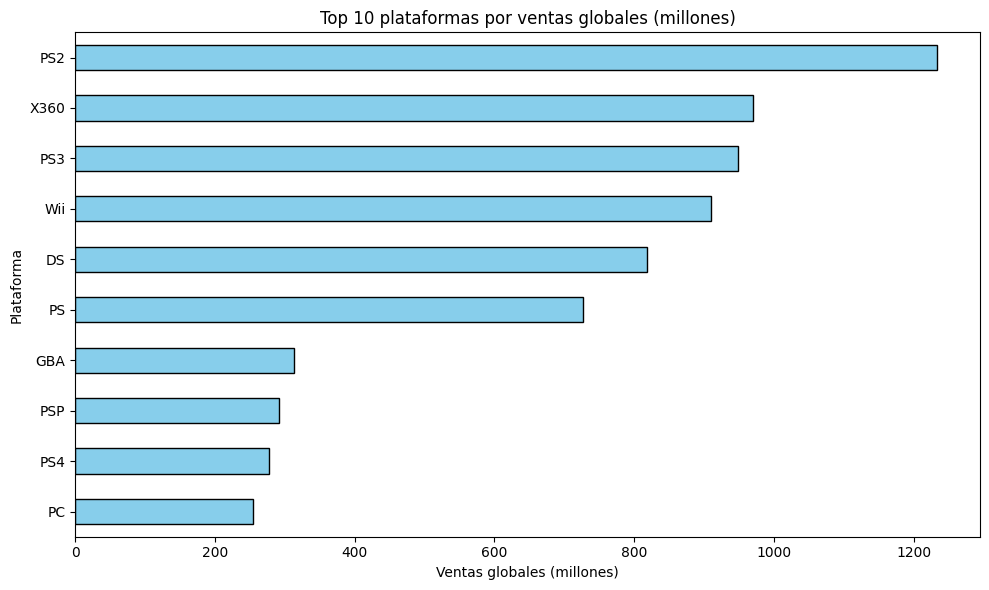

In [21]:
top_plataformas = df.groupby('Platform')['Global_Sales'].sum().sort_values(ascending=False).head(10)
print("\n=== Top 10 plataformas por ventas globales ===")
print(top_plataformas)

plt.figure(figsize=(10,6))
top_plataformas.plot(kind='barh', color='skyblue', edgecolor='black')
plt.title('Top 10 plataformas por ventas globales (millones)')
plt.xlabel('Ventas globales (millones)')
plt.ylabel('Plataforma')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('top_plataformas.png', dpi=150, bbox_inches='tight')
plt.show()

In [22]:
## Analisis por genero


=== Ventas globales por genero ===
Genre
Action          1722.88
Sports          1309.24
Shooter         1026.20
Role-Playing     923.84
Platform         829.15
Misc             797.62
Racing           726.77
Fighting         444.05
Simulation       390.16
Puzzle           242.22
Adventure        234.80
Strategy         173.43
Name: Global_Sales, dtype: float64


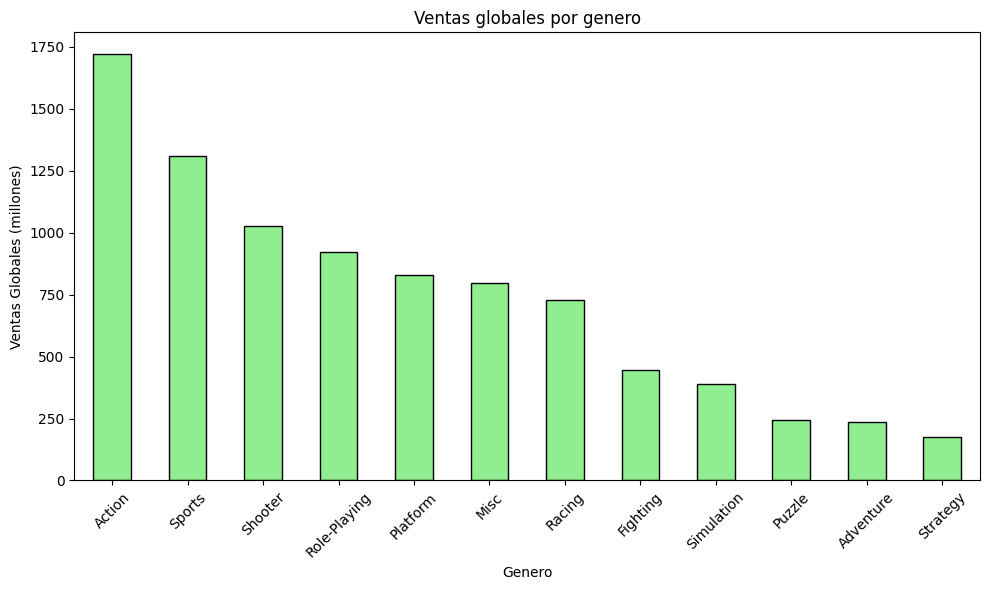

In [23]:
ventas_por_genero = df.groupby('Genre')['Global_Sales'].sum().sort_values(ascending=False)
print("\n=== Ventas globales por genero ===")
print(ventas_por_genero)

plt.figure(figsize=(10,6))
ventas_por_genero.plot(kind='bar', color='lightgreen', edgecolor='black')
plt.title('Ventas globales por genero')
plt.xlabel('Genero')
plt.ylabel('Ventas Globales (millones)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('ventas_por_genero.png', dpi=150, bbox_inches='tight')
plt.show()

In [24]:
## Evolucion temporal de ventas globales


=== Ventas globales por año (ultimos 10) ===
Year
2009    667.30
2010    600.45
2011    515.99
2012    363.54
2013    368.11
2014    337.05
2015    264.44
2016     70.93
2017      0.05
2020      0.29
Name: Global_Sales, dtype: float64


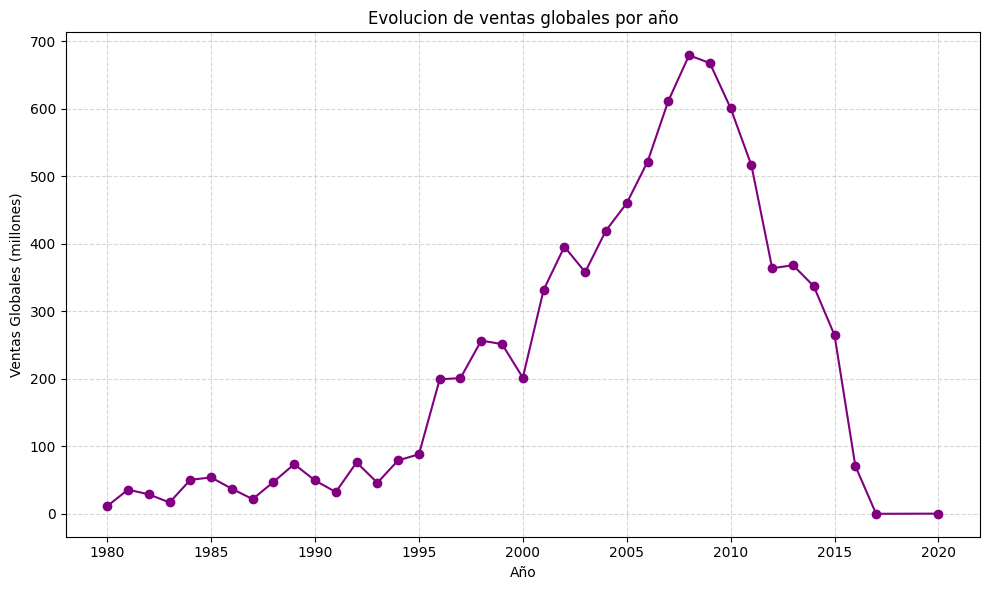

In [28]:
ventas_por_anio = df.groupby('Year')['Global_Sales'].sum()
print("\n=== Ventas globales por año (ultimos 10) ===")
print(ventas_por_anio.tail(10))

plt.figure(figsize=(10,6))
ventas_por_anio.plot(kind='line', marker='o', color='purple')
plt.title('Evolucion de ventas globales por año')
plt.xlabel('Año')
plt.ylabel('Ventas Globales (millones)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('evolucion_ventas.png', dpi=150, bbox_inches='tight')
plt.show()

In [29]:
## Top publishers por ventas totales

In [31]:
top_publishers = df.groupby('Publisher')['Global_Sales'].sum().sort_values(ascending=False).head(10)
print("\n=== Top 10 publishers por ventas globales ===")
print(top_publishers)


=== Top 10 publishers por ventas globales ===
Publisher
Nintendo                        1784.43
Electronic Arts                 1093.39
Activision                       721.41
Sony Computer Entertainment      607.28
Ubisoft                          473.54
Take-Two Interactive             399.30
THQ                              340.44
Konami Digital Entertainment     278.56
Sega                             270.70
Namco Bandai Games               253.65
Name: Global_Sales, dtype: float64


In [32]:
## Insights

In [33]:
print("\n=== Insights ===")
print("1. El genero de action, sports y shooter son los mas vendidos")
print("2. Las plataformas PS2, X360 y PS3 son las que tienen mas ventas")
print("3. A partir del año 2010 se nota una caida constante en las ventas globales, lo que puede deberse a la saturación del mercado o al cambio en los habitos de consumo hacia juegos moviles y digitales.")


=== Insights ===
1. El genero de action, sports y shooter son los mas vendidos
2. Las plataformas PS2, X360 y PS3 son las que tienen mas ventas
3. A partir del año 2010 se nota una caida constante en las ventas globales, lo que puede deberse a la saturación del mercado o al cambio en los habitos de consumo hacia juegos moviles y digitales.
